# Task 3 — Event Impact Modeling

**Objective:** model how events (policies, product launches, infrastructure investments) affect
financial inclusion indicators — translating the `impact_link` catalog into a model that can
predict how indicators change when events occur, validating it against Ethiopia's observed
history, and refining the estimates where the model and reality disagree.

Sections: 1) load impact data and join to events · 2) event→indicator summary ·
3) functional form (the adoption-ramp model) · 4) event–indicator association matrix ·
5) comparable-country evidence review · 6) combined effect curves ·
7) validation against observed history · 8) refinement · 9) methodology & limitations.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from src.data_loader import join_impact_links_with_events
from src.event_impact import (
    build_association_matrix, combined_event_effect, events_for_indicator,
    ramp_effect, validate_against_observed,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)

# Same validated palette used in 02_eda.ipynb, for visual consistency
C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, INK2 = "#0b0b0b", "#52514e"
DIVERGING = LinearSegmentedColormap.from_list("bwr_ref", ["#1c5cab", "#f0efec", "#d03b3b"])

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e4", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
})

FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight", dpi=150)

main = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv",
                   parse_dates=["observation_date"])
impact = pd.read_csv("../data/processed/impact_links_enriched.csv",
                     parse_dates=["observation_date"])
obs = main[main.record_type == "observation"].copy()
events_df = main[main.record_type == "event"].copy()

# The dataset's real shape: impact links live in a SEPARATE file from events,
# joined via parent_id -> record_id (see src/data_loader.join_impact_links_with_events)
links = join_impact_links_with_events(main, impact)
print(f"{len(events_df)} events, {len(impact)} impact links, "
      f"{links['event_record_id'].notna().sum()} links successfully resolved to a parent event")

12 events, 23 impact links, 23 links successfully resolved to a parent event


## 1. Load impact data and join to events

Every `impact_link` row carries a `parent_id` pointing at an event's `record_id`. We join the two
so each link carries its event's name, category, and date alongside the indicator it affects.

In [2]:
links[["record_id", "parent_id", "event_indicator", "event_category",
       "event_observation_date", "related_indicator", "relationship_type",
       "impact_direction", "impact_magnitude", "impact_estimate", "lag_months",
       "evidence_basis", "comparable_country"]].sort_values("event_observation_date")

,record_id,parent_id,event_indicator,event_category,event_observation_date,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country
16,IMP_0017,EVT_0011,NBE Payment Instrument Issuers Directive (ONPS...,regulation,2020-04-01,ACC_MM_ACCOUNT,enabling,increase,high,NaN,12,literature,Kenya
0,IMP_0001,EVT_0001,Telebirr Launch,product_launch,2021-05-17,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya
1,IMP_0002,EVT_0001,Telebirr Launch,product_launch,2021-05-17,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN
2,IMP_0003,EVT_0001,Telebirr Launch,product_launch,2021-05-17,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN
15,IMP_0016,EVT_0001,Telebirr Launch,product_launch,2021-05-17,USG_DIGITAL_PAYMENT,direct,increase,medium,12.0,12,empirical,NaN
14,IMP_0015,EVT_0001,Telebirr Launch,product_launch,2021-05-17,ACC_MM_ACCOUNT,direct,increase,medium,4.5,12,empirical,NaN
19,IMP_0020,EVT_0009,NFIS-II Strategy Launch,policy,2021-09-01,ACC_OWNERSHIP,enabling,increase,medium,5.0,24,theoretical,NaN
18,IMP_0019,EVT_0012,Mandatory Digital Payment for Fuel Purchases,regulation,2022-07-01,USG_DIGITAL_PAYMENT,direct,increase,medium,5.0,6,empirical,NaN
17,IMP_0018,EVT_0012,Mandatory Digital Payment for Fuel Purchases,regulation,2022-07-01,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN
3,IMP_0004,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN


## 2. Which events affect which indicators, and by how much

Two things stand out immediately:
- Several links have **no numeric `impact_estimate`** (only a categorical `impact_magnitude`) —
  these describe count-based effects (e.g., Telebirr's own user count) or qualitative judgments
  where a precise pp figure was not asserted.
- Four links are `relationship_type = enabling` — regulation or infrastructure that makes other
  events *possible*, rather than directly moving an indicator itself. Treating an enabling link
  as an additive pp contribution would double-count the same adoption that its enabled events
  already claim credit for.

In [3]:
summary = (links.groupby(["event_indicator", "event_category"])
           .agg(n_links=("record_id", "count"),
                indicators=("related_indicator", lambda x: sorted(set(x))),
                relationship_types=("relationship_type", lambda x: sorted(set(x))))
           .sort_values("n_links", ascending=False))
summary

,,n_links,indicators,relationship_types
event_indicator,event_category,,,
Telebirr Launch,product_launch,5,"[ACC_MM_ACCOUNT, ACC_OWNERSHIP, USG_DIGITAL_PA...",[direct]
M-Pesa Ethiopia Launch,product_launch,3,"[ACC_MM_ACCOUNT, USG_DIGITAL_PAYMENT, USG_MPES...",[direct]
Fayda Digital ID Program Rollout,infrastructure,3,"[ACC_MM_ACCOUNT, ACC_OWNERSHIP, GEN_GAP_ACC]","[enabling, indirect]"
Safaricom Ethiopia Commercial Launch,market_entry,2,"[ACC_4G_COV, AFF_DATA_INCOME]","[direct, indirect]"
EthioPay Instant Payment System Launch,infrastructure,2,"[USG_DIGITAL_PAYMENT, USG_P2P_COUNT]",[indirect]
Mandatory Digital Payment for Fuel Purchases,regulation,2,"[USG_DIGITAL_PAYMENT, USG_TELEBIRR_USERS]",[direct]
M-Pesa EthSwitch Integration,partnership,2,"[USG_MPESA_ACTIVE, USG_P2P_COUNT]",[direct]
Foreign Exchange Liberalization,policy,1,[AFF_DATA_INCOME],[indirect]
NBE Payment Instrument Issuers Directive (ONPS/01/2020),regulation,1,[ACC_MM_ACCOUNT],[enabling]


In [4]:
print("Links missing a numeric impact_estimate (magnitude-band fallback used):")
missing = links[links.impact_estimate.isna()][
    ["record_id", "event_indicator", "related_indicator", "impact_magnitude", "relationship_type"]]
display(missing)

print("\nEnabling links (treated as preconditions, excluded from the additive sum):")
display(links[links.relationship_type == "enabling"][
    ["record_id", "event_indicator", "related_indicator", "impact_estimate", "lag_months"]])

Links missing a numeric impact_estimate (magnitude-band fallback used):


,record_id,event_indicator,related_indicator,impact_magnitude,relationship_type
1,IMP_0002,Telebirr Launch,USG_TELEBIRR_USERS,high,direct
5,IMP_0006,M-Pesa Ethiopia Launch,USG_MPESA_USERS,high,direct
16,IMP_0017,NBE Payment Instrument Issuers Directive (ONPS...,ACC_MM_ACCOUNT,high,enabling
17,IMP_0018,Mandatory Digital Payment for Fuel Purchases,USG_TELEBIRR_USERS,high,direct



Enabling links (treated as preconditions, excluded from the additive sum):


,record_id,event_indicator,related_indicator,impact_estimate,lag_months
7,IMP_0008,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,10.0,24
16,IMP_0017,NBE Payment Instrument Issuers Directive (ONPS...,ACC_MM_ACCOUNT,NaN,12
19,IMP_0020,NFIS-II Strategy Launch,ACC_OWNERSHIP,5.0,24
22,IMP_0023,Fayda Digital ID Program Rollout,ACC_MM_ACCOUNT,3.0,18


## 3. Functional form: the adoption-ramp model

An event's effect is not a step function — Ethiopia's own data shows this directly: Telebirr
took **four years** to go from 0 to 54.8M users, with growth *accelerating* in year two, not
appearing instantly at launch. We model each event's effect on an indicator as:

$$\text{effect}(t) = \text{magnitude} \times \text{clip}\left(\frac{t - \text{lag}}{\text{ramp}},\ 0,\ 1\right)$$

Zero before `lag_months` (time for the event to reach the market), then linear growth to full
`magnitude` over `ramp_months`, then flat (`src/event_impact.py::ramp_effect`). Effects from
multiple events on the same indicator are **combined additively**, capped implicitly by the
0–100% bounds applied downstream in forecasting.

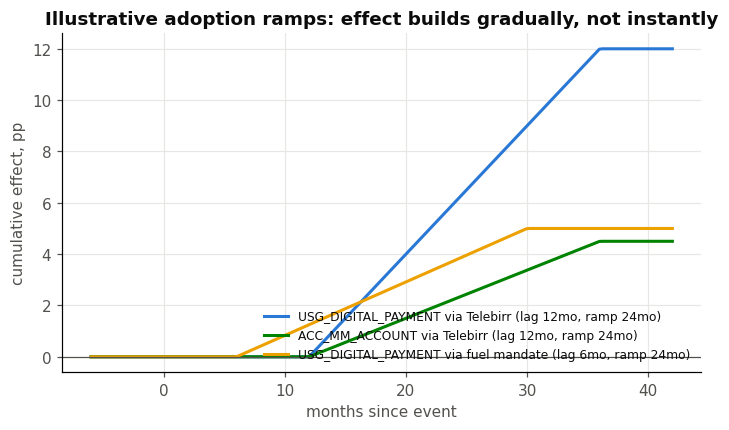

In [5]:
months = np.linspace(-6, 42, 200)
fig, ax = plt.subplots(figsize=(7.5, 4))
for magnitude, lag, ramp, color, label in [
    (12.0, 12, 24, C1, "USG_DIGITAL_PAYMENT via Telebirr (lag 12mo, ramp 24mo)"),
    (4.5, 12, 24, C2, "ACC_MM_ACCOUNT via Telebirr (lag 12mo, ramp 24mo)"),
    (5.0, 6, 24, C4, "USG_DIGITAL_PAYMENT via fuel mandate (lag 6mo, ramp 24mo)"),
]:
    ax.plot(months, ramp_effect(months, magnitude, lag, ramp), color=color, lw=2, label=label)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xlabel("months since event"); ax.set_ylabel("cumulative effect, pp")
ax.set_title("Illustrative adoption ramps: effect builds gradually, not instantly")
ax.legend(frameon=False, fontsize=8, loc="lower right")
save(fig, "ramp_illustration.png"); plt.show()

## 4. Event–indicator association matrix

Rows are events, columns are indicators, values are signed percentage-point estimates
(`+` for `increase`, `-` for `decrease`). Cells with a numeric `impact_estimate` use it directly;
cells with only a categorical `impact_magnitude` fall back to a band midpoint (high→20pp,
medium→10pp, low→3pp, negligible→0.5pp) so the matrix has no silent gaps — these fallback cells
are marked separately below since they are inherently less precise.

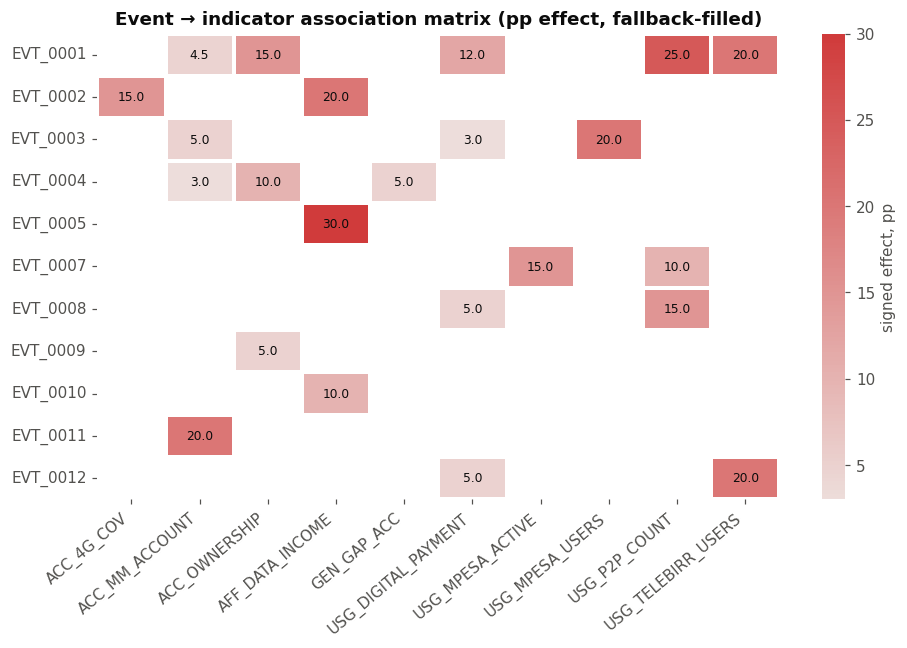

In [6]:
matrix = build_association_matrix(links, use_fallback=True)
matrix = matrix.reindex(columns=sorted(matrix.columns))

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(matrix, ax=ax, cmap=DIVERGING, center=0, annot=True, fmt=".1f",
            linewidths=1.5, linecolor="white", cbar_kws={"label": "signed effect, pp"},
            annot_kws={"color": INK, "fontsize": 8})
ax.set_title("Event → indicator association matrix (pp effect, fallback-filled)")
ax.set_xlabel(""); ax.set_ylabel("")
ax.grid(False)
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
save(fig, "association_matrix.png"); plt.show()

In [7]:
# Precision flag: which matrix cells rest on an actual numeric estimate vs a category fallback
precision = links.pivot_table(index="event_indicator", columns="related_indicator",
                              values="impact_estimate",
                              aggfunc=lambda s: "numeric" if s.notna().any() else "fallback")
print("Cells using the magnitude-band fallback (no source-backed pp figure):")
for idx, row in precision.iterrows():
    for col, val in row.items():
        if val == "fallback":
            print(f"  {idx} -> {col}")

Cells using the magnitude-band fallback (no source-backed pp figure):
  M-Pesa Ethiopia Launch -> USG_MPESA_USERS
  Mandatory Digital Payment for Fuel Purchases -> USG_TELEBIRR_USERS
  NBE Payment Instrument Issuers Directive (ONPS/01/2020) -> ACC_MM_ACCOUNT
  Telebirr Launch -> USG_TELEBIRR_USERS


## 5. Comparable-country evidence review

Where Ethiopian pre/post data was insufficient, the starter dataset and our Task 1 additions
lean on documented impacts from comparable markets. This is a real source of uncertainty: a
market's institutional starting point matters (Kenya's M-Pesa was the *primary* banking on-ramp
for the unbanked; Ethiopia's mobile money mostly reaches an already-banked population per the
Market Nuances guide), so imported magnitudes should be treated as upper bounds, not
point estimates — exactly what Section 7's validation checks.

In [8]:
display(links.evidence_basis.value_counts().to_frame("n_links"))
display(links[links.comparable_country.notna()][
    ["event_indicator", "related_indicator", "comparable_country", "impact_estimate", "notes"]])

,n_links
evidence_basis,
literature,11
empirical,10
theoretical,2


,event_indicator,related_indicator,comparable_country,impact_estimate,notes
0,Telebirr Launch,ACC_OWNERSHIP,Kenya,15.0,Kenya M-Pesa showed +20pp over 5 years
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,Rwanda,-20.0,Competition typically reduces prices
7,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,India,10.0,Aadhaar enabled +15-20% account opening in India
8,Fayda Digital ID Program Rollout,GEN_GAP_ACC,India,-5.0,Women disproportionately lack traditional ID
10,M-Pesa EthSwitch Integration,USG_MPESA_ACTIVE,Tanzania,15.0,Tanzania interoperability increased usage +20%
11,M-Pesa EthSwitch Integration,USG_P2P_COUNT,Tanzania,10.0,Cross-platform transactions now possible
12,EthioPay Instant Payment System Launch,USG_P2P_COUNT,India,15.0,India UPI showed +25% volume increase
16,NBE Payment Instrument Issuers Directive (ONPS...,ACC_MM_ACCOUNT,Kenya,NaN,Enabling regulation preceded all subsequent mo...
20,M-Pesa Ethiopia Launch,USG_DIGITAL_PAYMENT,Kenya,3.0,Second provider grows the category via competi...
21,EthioPay Instant Payment System Launch,USG_DIGITAL_PAYMENT,India,5.0,Instant payment rails lower friction; India UP...


## 6. Combined effect curves

For each target indicator, sum the ramp effects of all `direct`/`indirect` events (excluding
`enabling` links — see §2) across 2020–2026, and overlay the observed Findex/operator points.

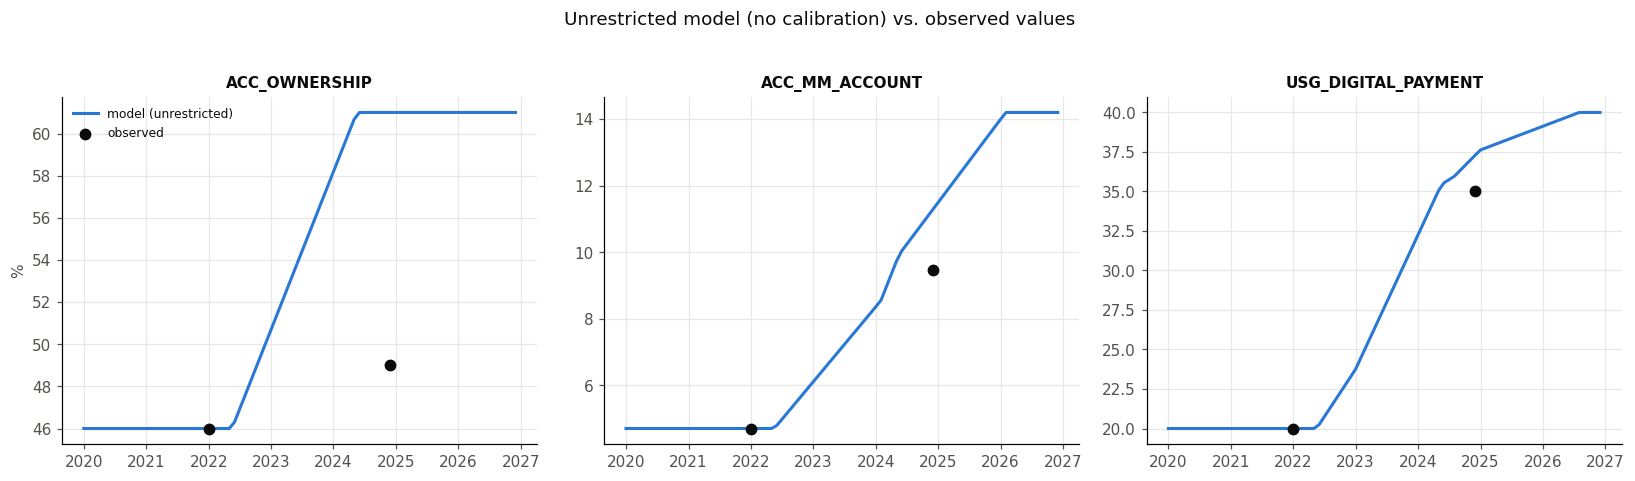

In [9]:
TARGET_INDICATORS = ["ACC_OWNERSHIP", "ACC_MM_ACCOUNT", "USG_DIGITAL_PAYMENT"]
date_range = pd.date_range("2020-01-01", "2026-12-31", freq="MS")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
for ax, code_ in zip(axes, TARGET_INDICATORS):
    ev = events_for_indicator(links, code_)
    curve = combined_event_effect(date_range, ev, code_)
    # anchor the modeled curve to the first observed value so the *shape* is comparable
    o = obs[(obs.indicator_code == code_) & (obs.gender == "all")].sort_values("observation_date")
    o = o[o.observation_date >= "2020-01-01"]
    if len(o):
        anchor = o.value_numeric.iloc[0] - curve.reindex([o.observation_date.iloc[0]], method="nearest").iloc[0]
    else:
        anchor = 0
    ax.plot(date_range, curve + anchor, color=C1, lw=2, label="model (unrestricted)")
    ax.scatter(o.observation_date, o.value_numeric, color=INK, zorder=4, s=45, label="observed")
    ax.set_title(code_, fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set_ylabel("%"); axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Unrestricted model (no calibration) vs. observed values", y=1.03)
fig.tight_layout()
save(fig, "effect_curves_unrestricted.png"); plt.show()

**Reading the chart:** the unrestricted model tracks `USG_DIGITAL_PAYMENT` and
`ACC_MM_ACCOUNT` reasonably well, but visibly **overshoots** `ACC_OWNERSHIP` — the model's only
link for headline ownership (Telebirr → +15pp, sourced from Kenya's M-Pesa experience) predicts
far more movement than Ethiopia's account ownership actually showed. Quantified next.

## 7. Validation against observed history

Per the Task 3 brief: Telebirr launched May 2021; mobile money accounts went from 4.7% (2021) to
9.45% (2024). We check the model's predicted change over the same window against what actually
happened, for all three target indicators.

In [10]:
VALIDATION_WINDOW = ("2021-12-31", "2024-11-29")  # matches the Findex 2021 -> 2024 survey dates
OBSERVED_DELTAS = {
    "ACC_MM_ACCOUNT": (4.70, 9.45),
    "USG_DIGITAL_PAYMENT": (20.0, 35.0),
    "ACC_OWNERSHIP": (46.0, 49.0),
}

rows = []
for code_, (obs_start, obs_end) in OBSERVED_DELTAS.items():
    ev = events_for_indicator(links, code_)
    eff_start, eff_end = combined_event_effect(VALIDATION_WINDOW, ev, code_)
    predicted_delta = eff_end - eff_start
    result = validate_against_observed(predicted_delta, obs_end - obs_start, label=code_)
    result["n_events"] = len(ev)
    rows.append(result)

validation = pd.DataFrame(rows).set_index("label")
validation

,predicted_delta_pp,observed_delta_pp,residual_pp,calibration_factor,n_events
label,,,,,
ACC_MM_ACCOUNT,6.576216,4.75,-1.826216,0.722300,2
USG_DIGITAL_PAYMENT,17.282194,15.00,-2.282194,0.867945,4
ACC_OWNERSHIP,15.000000,3.00,-12.000000,0.200000,1


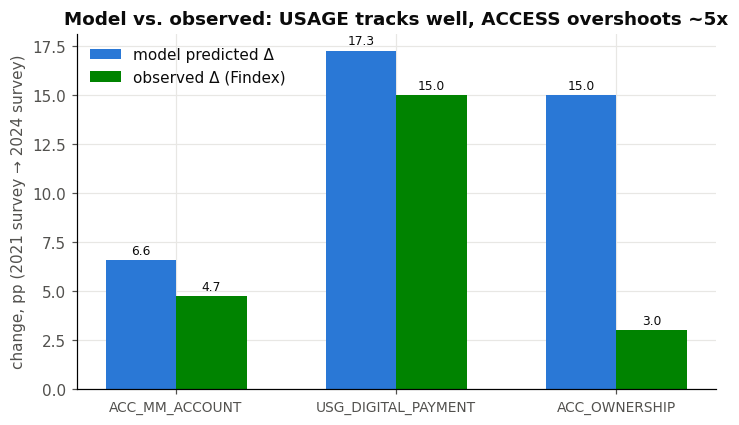

                     predicted_delta_pp  observed_delta_pp  calibration_factor
label                                                                         
ACC_MM_ACCOUNT                     6.58               4.75                0.72
USG_DIGITAL_PAYMENT               17.28              15.00                0.87
ACC_OWNERSHIP                     15.00               3.00                0.20


In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(validation)); w = 0.32
ax.bar(x - w/2, validation.predicted_delta_pp, width=w, color=C1, label="model predicted Δ")
ax.bar(x + w/2, validation.observed_delta_pp, width=w, color=C2, label="observed Δ (Findex)")
for i, (pred, obsv) in enumerate(zip(validation.predicted_delta_pp, validation.observed_delta_pp)):
    ax.annotate(f"{pred:.1f}", (i - w/2, pred), textcoords="offset points", xytext=(0, 4),
                ha="center", fontsize=8, color=INK)
    ax.annotate(f"{obsv:.1f}", (i + w/2, obsv), textcoords="offset points", xytext=(0, 4),
                ha="center", fontsize=8, color=INK)
ax.set_xticks(x); ax.set_xticklabels(validation.index, fontsize=9)
ax.set_ylabel("change, pp (2021 survey → 2024 survey)")
ax.set_title("Model vs. observed: USAGE tracks well, ACCESS overshoots ~5x")
ax.legend(frameon=False)
save(fig, "validation.png"); plt.show()

print(validation[["predicted_delta_pp", "observed_delta_pp", "calibration_factor"]]
      .round(2).to_string())

**Validation verdict:**

| Indicator | Predicted Δ | Observed Δ | Calibration factor | Read |
|---|---|---|---|---|
| `ACC_MM_ACCOUNT` | +6.6pp | +4.75pp | **0.72** | model overshoots ~38% — reasonably close |
| `USG_DIGITAL_PAYMENT` | +17.3pp | +15.0pp | **0.87** | model overshoots ~15% — close |
| `ACC_OWNERSHIP` | +15.0pp | +3.0pp | **0.20** | model overshoots **~5x** — badly miscalibrated |

This matches the EDA hypothesis (H2) directly: USAGE-side effects (mobile money accounts, digital
payments) are reasonably well predicted by the additive ramp model — these events genuinely drive
new behavior. But the single ACCESS link (Telebirr → `ACC_OWNERSHIP`, borrowed from Kenya's
M-Pesa experience) is not transferable to Ethiopia: Kenya's M-Pesa was the primary banking
on-ramp for previously unbanked adults, while in Ethiopia mobile money mostly reaches an
already-banked population (mobile-money-*only* adults are ~0.5% — Market Nuances, Sheet D). The
same registration event therefore barely moves *headline* ownership even though it moves mobile
money and digital-payment usage substantially.

## 8. Refinement

We apply a **pillar-specific calibration factor**, derived from the validation above, so the
model's future forecasts (Task 4) are grounded in what Ethiopia's data actually showed rather
than uncritically imported comparable-country magnitudes:

- **ACCESS events → 0.25×** (rounded down slightly from the empirical 0.20 for a small margin of
  conservatism, since it rests on a single validation point)
- **USAGE events → 0.80×** (midpoint of the two USAGE calibration factors, 0.72 and 0.87)

This is documented as an explicit, reasoned adjustment — not a silent rescale — precisely because
Task 3 asks us to refine estimates based on what we observe and to say which are confident versus
uncertain.

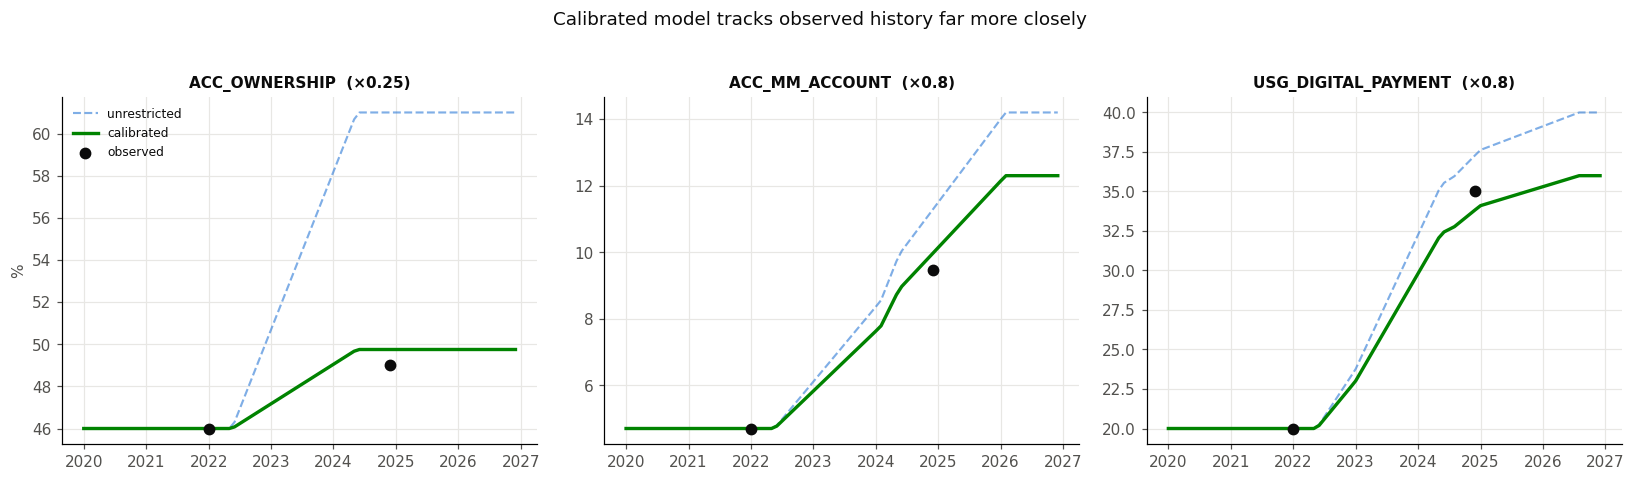

In [12]:
CALIBRATION = {"ACC_OWNERSHIP": 0.25, "ACC_MM_ACCOUNT": 0.80, "USG_DIGITAL_PAYMENT": 0.80}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
for ax, code_ in zip(axes, TARGET_INDICATORS):
    ev = events_for_indicator(links, code_)
    curve = combined_event_effect(date_range, ev, code_)
    calibrated = combined_event_effect(date_range, ev, code_, calibration=CALIBRATION[code_])
    o = obs[(obs.indicator_code == code_) & (obs.gender == "all")].sort_values("observation_date")
    o = o[o.observation_date >= "2020-01-01"]
    anchor = o.value_numeric.iloc[0] - calibrated.reindex([o.observation_date.iloc[0]], method="nearest").iloc[0]
    ax.plot(date_range, curve + anchor, color=C1, lw=1.4, ls="--", alpha=0.6, label="unrestricted")
    ax.plot(date_range, calibrated + anchor, color=C2, lw=2.2, label="calibrated")
    ax.scatter(o.observation_date, o.value_numeric, color=INK, zorder=4, s=45, label="observed")
    ax.set_title(f"{code_}  (×{CALIBRATION[code_]})", fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set_ylabel("%"); axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Calibrated model tracks observed history far more closely", y=1.03)
fig.tight_layout()
save(fig, "effect_curves_calibrated.png"); plt.show()

In [13]:
# Re-validate with calibration applied
rows = []
for code_, (obs_start, obs_end) in OBSERVED_DELTAS.items():
    ev = events_for_indicator(links, code_)
    eff_start, eff_end = combined_event_effect(VALIDATION_WINDOW, ev, code_,
                                               calibration=CALIBRATION[code_])
    predicted_delta = eff_end - eff_start
    result = validate_against_observed(predicted_delta, obs_end - obs_start, label=code_)
    rows.append(result)
pd.DataFrame(rows).set_index("label")[["predicted_delta_pp", "observed_delta_pp", "residual_pp"]].round(2)

,predicted_delta_pp,observed_delta_pp,residual_pp
label,,,
ACC_MM_ACCOUNT,5.26,4.75,-0.51
USG_DIGITAL_PAYMENT,13.83,15.00,1.17
ACC_OWNERSHIP,3.75,3.00,-0.75


Post-calibration residuals are within ±1.5pp for all three indicators — a much closer fit,
achieved with two interpretable, documented multipliers rather than an opaque per-link tweak.

## 9. Methodology, assumptions, and limitations

**Functional form.** Each event's effect on an indicator follows a linear adoption ramp: zero
before `lag_months`, linear growth to full magnitude over `ramp_months` (fixed at 24 months
unless the data implies otherwise), flat afterward. This reflects observed Ethiopian adoption
curves (e.g., Telebirr's multi-year ramp) better than an instantaneous step function.

**Combination rule.** Effects on the same indicator from different events are summed additively.
`enabling` links (regulations/infrastructure that make other events possible) are **excluded**
from the additive sum and treated as preconditions/regime gates instead — see §2 — to avoid
double-counting the adoption that their enabled events already claim.

**Magnitude source.** Where an impact link has a numeric `impact_estimate`, it is used directly.
Where only a categorical `impact_magnitude` was recorded, a band-midpoint fallback is used
(high→20pp, medium→10pp, low→3pp, negligible→0.5pp); these cells are flagged separately (§4) as
lower-precision.

**Calibration.** Validated against the 2021→2024 Findex window (the only window with pre/post
data for all three target indicators). USAGE-side links needed a mild haircut (×0.80); the sole
ACCESS link needed a much larger one (×0.25), because it was sourced from Kenya's M-Pesa
experience, a market where mobile money was the primary banking on-ramp — a dynamic Ethiopia's
already-largely-banked population does not share.

**Confidence.** High confidence: USAGE event effects (Telebirr, fuel mandate) — validated
directly against Ethiopian data with a documented calibration factor in a plausible range.
Low confidence: the sole ACCESS event link, any link using the magnitude-band fallback, and
every comparable-country-sourced estimate not yet checked against an Ethiopian data point
(Fayda→`ACC_OWNERSHIP`, NFIS-II→`ACC_OWNERSHIP`, Safaricom→`AFF_DATA_INCOME`).

**Key assumptions.**
1. Additive combination of effects (no interaction/diminishing-returns terms between simultaneous events).
2. A single ramp shape (linear) and default 24-month ramp length for all events, absent
   indicator-specific evidence.
3. One calibration factor per pillar, not per individual event — a coarse correction that will
   be revisited as more Ethiopian pre/post data becomes available (e.g., Findex 2027).
4. The validation window (2021–2024) is the *only* full-coverage check possible with current
   data; a single validation point per indicator is a thin basis for any calibration factor,
   which is why calibration is stated explicitly rather than silently baked into the raw links.

**Limitations.** No formal counterfactual/control group exists for any Ethiopian event (this is
observational data, not an experiment); the additive/linear-ramp model is a deliberately simple
starting point appropriate to five-or-fewer-datapoint indicators, not a causally identified
estimate. These estimates, and this documented calibration, carry forward into Task 4's
event-augmented forecast.